# Melanoma Classification with CNN
## EDA

 ¿cómo se ven las imágenes?, ¿cuántas hay de cada clase?, y ¿qué tamaños tienen?

In [27]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from torchvision.transforms import functional as F


> N° de imagenes

In [28]:
train_benign = os.listdir('data/train/Benign')
train_malignant = os.listdir('data/train/Malignant')

print(f"Train Benign tiene: {len(train_benign)} imagenes")
print(f"Train Malignant tiene: {len(train_malignant)} imagenes")
print(f"Total: {len(train_benign) + len(train_malignant)} imagenes")

Train Benign tiene: 6289 imagenes
Train Malignant tiene: 5590 imagenes
Total: 11879 imagenes


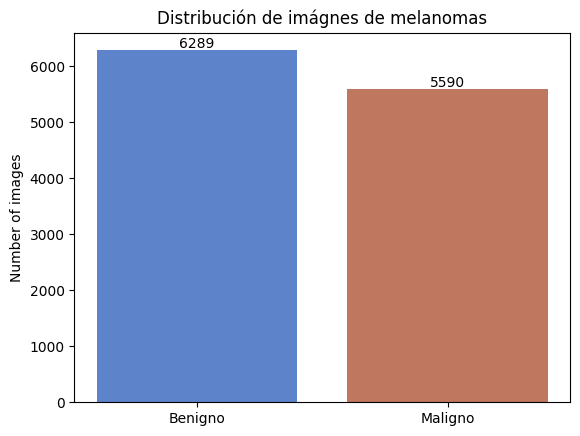

In [29]:
melanomas = ['Benigno', 'Maligno']
counts = [len(train_benign), len(train_malignant)]

plt.bar(melanomas, counts, color=["#5D83CA", "#C0775F"])
plt.title('Distribución de imágnes de melanomas')
plt.ylabel('Number of images')
for i, v in enumerate(counts):
    plt.text(i, v + 50, str(v), ha='center')
plt.show()

> Tenemos un número balanceado de imágenes para tratar los datos aprox 52% y 48%

> Cómo se ven estas imágenes

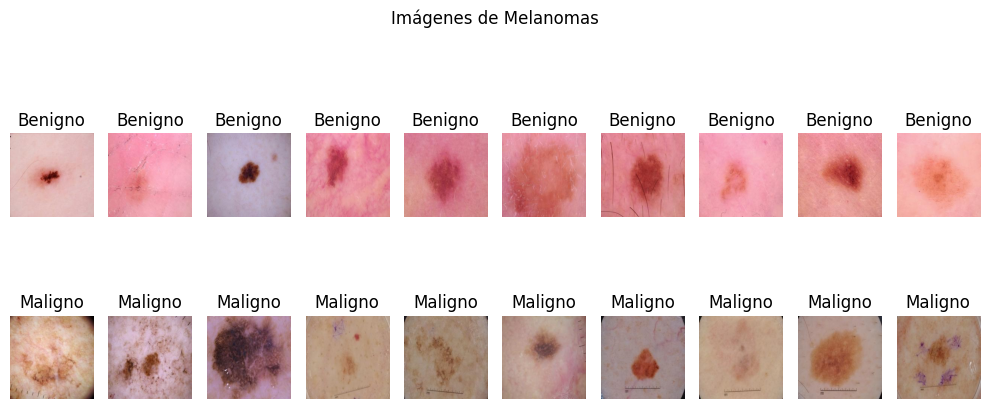

In [30]:
fig, axes = plt.subplots(2, 10, figsize=(10, 5))

for i in range(10):
    img = Image.open(f"data/train/Benign/{train_benign[i]}")
    axes[0][i].imshow(img)
    axes[0][i].set_title("Benigno")
    axes[0][i].axis('off')

for i in range(10):
    img = Image.open(f"data/train/Malignant/{train_malignant[i]}")
    axes[1][i].imshow(img)
    axes[1][i].set_title("Maligno")
    axes[1][i].axis('off')
plt.suptitle('Imágenes de Melanomas')
plt.tight_layout()
plt.show()

> Al observar las imágenes de muestra, se pueden identificar algunas diferencias entre clases:
- Las lesiones malignas tienden a presentar bordes un poco más irregulares
  con tonos diferentes para cada lesión.
- Las lesiones benignas suelen ser más uniformes en color (un poco de color rojo, pero podría tratarse de la luz con la que fue tomada), con bordes más suaves 
  y formas más redondeadas.
- Las Benignas también parecen tener mayor densidad de pigmento concentrado.

> Tamaño de imágenes

In [31]:
widths = []
heights = []

for img_name in train_benign[:200]:
    img = Image.open(f'data/train/Benign/{img_name}')
    widths.append(img.size[0])
    heights.append(img.size[1])

for img_name in train_malignant[:200]:
    img = Image.open(f'data/train/Malignant/{img_name}')
    widths.append(img.size[0])
    heights.append(img.size[1])

print(f"Width  - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.0f}")
print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.0f}")

Width  - Min: 224, Max: 224, Mean: 224
Height - Min: 224, Max: 224, Mean: 224


> Las imágenes estan en 224x224 píxeles, lo ual es un tamaño estándar en visión. Esto es bueno ya que no tendré que redimensionar

#### Augmentacion de datos + técnica de mejejora de imágenes: Normalización y Ecualizacion de histograma

> Augmentación es rear variaciones artificiales de tus imágenes para que el modelo aprenda mejor.

In [32]:
# imágenes solo con ToTensor para calcular estadísticas
temp_dataset = datasets.ImageFolder('data/train', transform=transforms.ToTensor())
temp_loader = DataLoader(temp_dataset, batch_size=64, shuffle=False)

# Calcular media y std por canal RGB
mean = torch.zeros(3)
std = torch.zeros(3)
total_images = 0

for images, _ in temp_loader:
    batch_size = images.size(0)
    images = images.view(batch_size, 3, -1)  # Aplanar cada canal
    mean += images.mean(2).sum(0)
    std += images.std(2).sum(0)
    total_images += batch_size

mean /= total_images
std /= total_images

print(f"Mean: {mean}")
print(f"Std: {std}")

Mean: tensor([0.7230, 0.5556, 0.5390])
Std: tensor([0.1209, 0.1340, 0.1448])


> Decidí calcular la media y desviación estándar directamente sobre el dataset  en lugar de utilizar los valores estándar. Dado que nuestras imágenes son  específicamente de lesiones dermatológicas, sus características de color (tonos de piel,  pigmentación) son diferentes a las de un dataset general. Usar los valores reales de los datos permite una normalización más precisa y adaptada al problema, esperando que esto resulte en que pueda contribuir a un mejor rendimiento del modelo.

> Ecualización de histograma, mejora el contraste de la imagen redistribuyendo la intensidad de los píxeles. Para las imágenes de melanomas ayudará a que las diferencias de color en la lesión se vean más marcadas. Como trabaha con imagenes PIL tiene que ir ANTES DE CONVERTIR IMAGENES A TENSORES

In [ ]:
class HistogramEqualization:
    def __call__(self, img):
        return F.equalize(img)

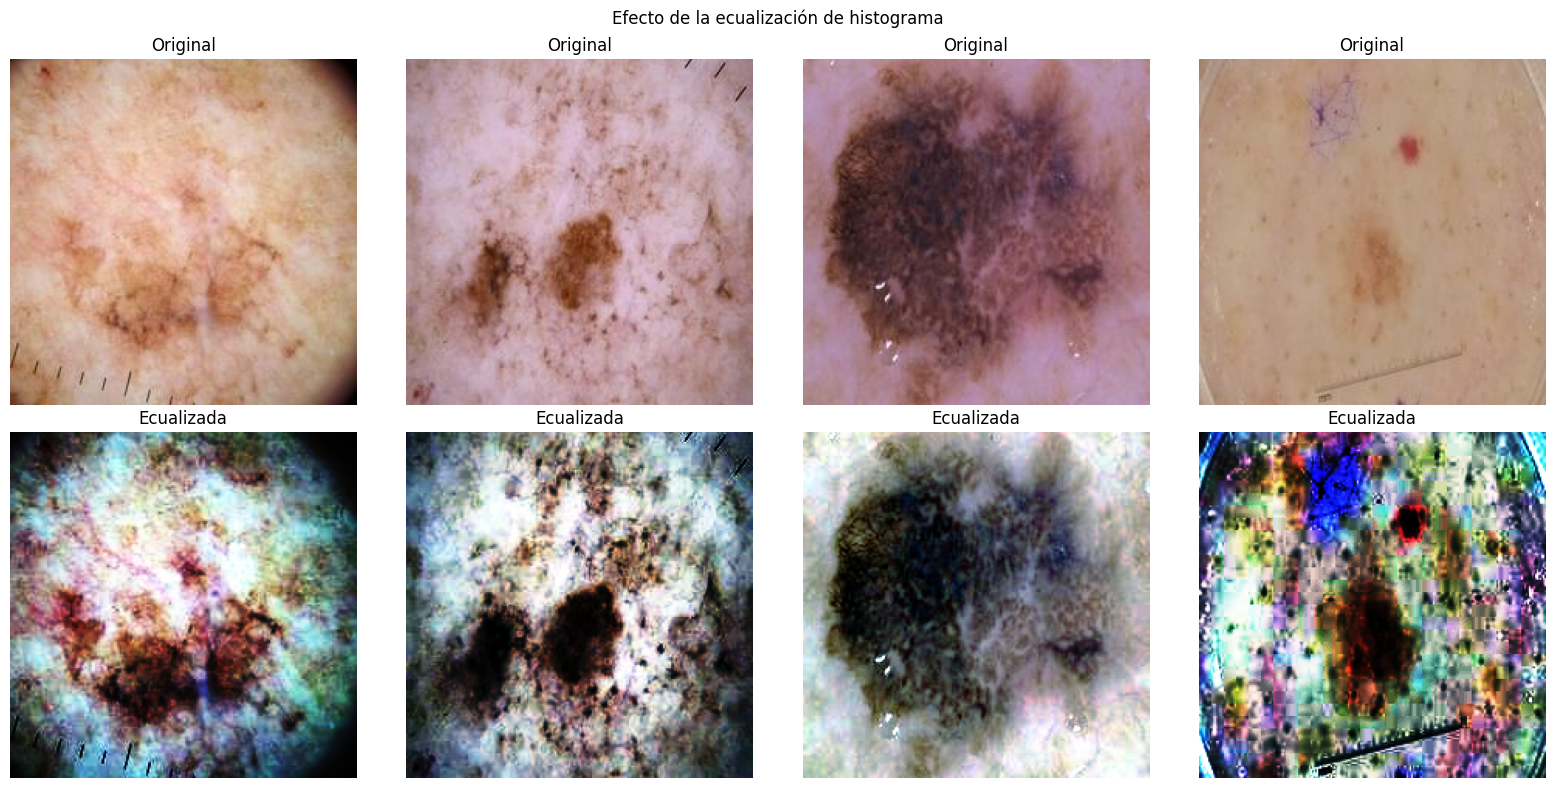

In [37]:
from torchvision.transforms import functional as F

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    img = Image.open(f'data/train/Malignant/{train_malignant[i]}')
    img_eq = F.equalize(img)
    
    axes[0][i].imshow(img)
    axes[0][i].set_title('Original')
    axes[0][i].axis('off')
    
    axes[1][i].imshow(img_eq)
    axes[1][i].set_title('Ecualizada')
    axes[1][i].axis('off')

plt.suptitle('Efecto de la ecualización de histograma')
plt.tight_layout()
plt.show()

> Ejemplo de ecualización de histograma: Las imágenes originales con las ecualizadas, se observa que el contraste aumenta , resaltando los bordes y las variaciones de pigmentación dentro de las lesiones. Aunque introduce tonos artificiales, esto puede beneficiar al modelo al hacer más evidentes las diferencias de textura y color que caracterizan a las esiones malignas. Por esto las incluiré en las transformaciones

In [34]:
#Transformaciones para el dataset de train

train_transform = transforms.Compose([
    HistogramEqualization(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.7230, 0.5556, 0.5390], std=[0.1209, 0.1340, 0.1448])
])

#Transformaciones para el dataset de test

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.7230, 0.5556, 0.5390], std=[0.1209, 0.1340, 0.1448])
])

- Horizontal flip: voltea imagen horizontalmente con 50% de probabilidad
- Random Vertical Flip(): Igual pero vertical
- Random rotation: rota imagenes cieirtos grados en cualquier dirección
- colorjitter : cambia brillo y contraste
- To Tnesor: convertir imagen de pixs a tensores (0 a 1) para que PyTorch pueda leerlos
- Normalize: estandariza valores de cada canal a partir de mis datos, asi los valores en vez de ir de 0 a 1 van alrededor del 0 con positivos y negaticos. Esto ayuda a que la red aprenda más rápido porque no se debe compoensar eñ "sesgo inicial"

## 2. Diseño y entrenamiento de la CNN

> Carga de datos y separación

In [35]:
train_data = datasets.ImageFolder('data/train', transform=train_transform)
test_data = datasets.ImageFolder('data/test', transform=test_transform)

> Single split en tres conjuntos: train (para aprender), validation (para monitorear durante el entrenamiento) y test (para evaluar al final).

>Los data loaders es dividir todo en batches para no reventar la compu

In [36]:
# Separar train y validate
train_size = int(0.8 * len(train_data))
val_size = len(train_data) - train_size
train_subset, val_subset = random_split(train_data, [train_size, val_size])

#dataloaders
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)


print(f"TRAIN: {len(train_subset)} images")
print(f"VALIDATION: {len(val_subset)} images")
print(f"TEST: {len(test_data)} images")
print(f"CLASES: {train_data.classes}")

TRAIN: 9503 images
VALIDATION: 2376 images
TEST: 2000 images
CLASES: ['Benign', 'Malignant']
